In [6]:
import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

RUNNING_IN_COLAB = True  # set False if running outside Colab

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    CH4_DIR = '/content/drive/MyDrive/FEMTO-ST/processed_features'   # Chapter 4 output
    CH5_DIR = '/content/drive/MyDrive/FEMTO-ST/chapter5_outputs'     # Chapter 5 output
    OUTPUT_DIR = '/content/drive/MyDrive/FEMTO-ST/chapter6_outputs'
else:
    CH4_DIR = '/home/claude/processed_features'
    CH5_DIR = '/home/claude/chapter5_outputs'
    OUTPUT_DIR = '/home/claude/chapter6_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(os.path.join(CH5_DIR, "best_model_parameters.json")) as f:
    ch5_summary = json.load(f)
print("Chapter 5 selected model:", ch5_summary["selected_model"],
      "| feature set:", ch5_summary["selected_feature_set"],
      "| test MAE:", round(ch5_summary["test_MAE"], 2))

best_model = joblib.load(os.path.join(CH5_DIR, "best_model.pkl"))

df = pd.read_csv(os.path.join(CH4_DIR, f"features_{ch5_summary['selected_feature_set']}.csv"))
META_COLS = ["set", "bearing", "condition", "snapshot_idx", "has_temperature",
             "total_life_snapshots", "RUL_snapshots"]
feature_cols = [c for c in df.columns if c not in META_COLS]

assert len(feature_cols) == ch5_summary["n_features"], \
    "Feature count mismatch vs Chapter 5 -- check Chapter 4 outputs haven't changed."

df["RUL_pct"] = df["RUL_snapshots"] / df["total_life_snapshots"] * 100
print(f"Loaded {df.shape[0]} rows, {len(feature_cols)} features (matches Chapter 5 exactly).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Chapter 5 selected model: CatBoost | feature set: time_frequency | test MAE: 18.45
Loaded 7534 rows, 30 features (matches Chapter 5 exactly).


In [7]:
!pip install catboost

In [8]:
TRAIN_BEARINGS = ["Bearing1_1", "Bearing2_1"]
CALIB_BEARING = "Bearing3_1"
TEST_BEARINGS = ["Bearing1_2", "Bearing2_2", "Bearing3_2"]  # identical to Chapter 5's test set

train_df = df[df["bearing"].isin(TRAIN_BEARINGS)].reset_index(drop=True)
calib_df = df[df["bearing"] == CALIB_BEARING].reset_index(drop=True)
test_df  = df[df["bearing"].isin(TEST_BEARINGS)].reset_index(drop=True)

X_train, y_train = train_df[feature_cols], train_df["RUL_pct"]
X_calib, y_calib = calib_df[feature_cols], calib_df["RUL_pct"]
X_test,  y_test  = test_df[feature_cols],  test_df["RUL_pct"]

print(f"Train : {X_train.shape}  bearings={TRAIN_BEARINGS}")
print(f"Calib : {X_calib.shape}  bearing={CALIB_BEARING}")
print(f"Test  : {X_test.shape}  bearings={TEST_BEARINGS}")


Train : (3714, 30)  bearings=['Bearing1_1', 'Bearing2_1']
Calib : (515, 30)  bearing=Bearing3_1
Test  : (3305, 30)  bearings=['Bearing1_2', 'Bearing2_2', 'Bearing3_2']


In [9]:
ALPHA = 0.10  # target: 90% prediction interval

# Dedicated XGBoost hyperparameters for the quantile models.
# These are intentionally separate from the Chapter 5 CatBoost parameters,
# because the point model and CQR quantile models use different algorithms.
QUANTILE_PARAMS = {
    "n_estimators": 100,
    "learning_rate": 0.01,
    "max_depth": 6,
    "random_state": RANDOM_STATE
}

q_lo_model = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=ALPHA / 2,
    **QUANTILE_PARAMS
)

q_hi_model = xgb.XGBRegressor(
    objective="reg:quantileerror",
    quantile_alpha=1 - ALPHA / 2,
    **QUANTILE_PARAMS
)

q_lo_model.fit(X_train, y_train)
q_hi_model.fit(X_train, y_train)

print(
    f"Trained lower (q={ALPHA/2:.2f}) and "
    f"upper (q={1-ALPHA/2:.2f}) quantile models."
)

Trained lower (q=0.05) and upper (q=0.95) quantile models.


In [10]:
calib_lo_raw = q_lo_model.predict(X_calib)
calib_hi_raw = q_hi_model.predict(X_calib)

# Nonconformity score: how far outside the raw interval the true value fell (negative = inside)
E = np.maximum(calib_lo_raw - y_calib.values, y_calib.values - calib_hi_raw)

n_calib = len(E)
q_level = min(1.0, np.ceil((n_calib + 1) * (1 - ALPHA)) / n_calib)
q_hat = np.quantile(E, q_level)

print(f"Calibration set size: {n_calib}")
print(f"Conformal correction q_hat = {q_hat:.3f}  (added/subtracted from raw quantile bounds)")


Calibration set size: 515
Conformal correction q_hat = 0.850  (added/subtracted from raw quantile bounds)


In [11]:
test_lo = np.clip(q_lo_model.predict(X_test) - q_hat, 0, 100)
test_hi = np.clip(q_hi_model.predict(X_test) + q_hat, 0, 100)
test_point = best_model.predict(X_test)
test_width = test_hi - test_lo

# Confidence classification from interval width, per publication-readiness suggestion.
# Tertiles (33rd/67th percentile of THIS test set's widths) are used rather than fixed absolute
# thresholds, since "small/medium/large" is inherently relative to the width distribution actually
# produced by this calibration -- a fixed cutoff (e.g. "<10 points = high confidence") would be
# arbitrary and would silently break if re-run with a different calibration set size or ALPHA.
width_tertile_low, width_tertile_high = np.quantile(test_width, [1/3, 2/3])
print(f"Confidence tertile cutoffs: <{width_tertile_low:.1f} = High, "
      f"{width_tertile_low:.1f}-{width_tertile_high:.1f} = Moderate, >{width_tertile_high:.1f} = Low")

def confidence_label(w):
    if w < width_tertile_low:
        return "High"
    elif w < width_tertile_high:
        return "Moderate"
    else:
        return "Low"

test_confidence = np.array([confidence_label(w) for w in test_width])

prediction_with_intervals = test_df[["bearing", "condition", "snapshot_idx", "RUL_snapshots"]].copy()
prediction_with_intervals["actual_RUL_pct"] = y_test.values
prediction_with_intervals["predicted_RUL_pct"] = test_point
prediction_with_intervals["lower_bound_pct"] = test_lo
prediction_with_intervals["upper_bound_pct"] = test_hi
prediction_with_intervals["interval_width_pct"] = test_width
prediction_with_intervals["confidence"] = test_confidence

intervals_path = os.path.join(OUTPUT_DIR, "prediction_with_intervals.csv")
prediction_with_intervals.to_csv(intervals_path, index=False)
print(f"Saved -> {intervals_path}  {prediction_with_intervals.shape}")
print(prediction_with_intervals["confidence"].value_counts())
prediction_with_intervals.head(10)


Confidence tertile cutoffs: <79.8 = High, 79.8-82.8 = Moderate, >82.8 = Low
Saved -> /content/drive/MyDrive/FEMTO-ST/chapter6_outputs/prediction_with_intervals.csv  (3305, 10)
confidence
Moderate    1108
Low         1103
High        1094
Name: count, dtype: int64


,bearing,condition,snapshot_idx,RUL_snapshots,actual_RUL_pct,predicted_RUL_pct,lower_bound_pct,upper_bound_pct,interval_width_pct,confidence
0,Bearing1_2,Condition 1,1,870,99.885189,74.791506,9.406838,98.099268,88.692430,Low
1,Bearing1_2,Condition 1,2,869,99.770379,76.643122,9.412666,98.099268,88.686602,Low
2,Bearing1_2,Condition 1,3,868,99.655568,76.182195,9.419085,97.994776,88.575691,Low
3,Bearing1_2,Condition 1,4,867,99.540758,76.500638,9.090974,97.994776,88.903802,Low
4,Bearing1_2,Condition 1,5,866,99.425947,76.806064,9.090974,98.015398,88.924425,Low
5,Bearing1_2,Condition 1,6,865,99.311137,76.746582,9.090974,98.084551,88.993577,Low
6,Bearing1_2,Condition 1,7,864,99.196326,76.343681,9.090974,98.012224,88.921251,Low
7,Bearing1_2,Condition 1,8,863,99.081515,75.908194,9.680334,97.917818,88.237484,Low
8,Bearing1_2,Condition 1,9,862,98.966705,75.676696,9.452078,97.050814,87.598736,Low
9,Bearing1_2,Condition 1,10,861,98.851894,75.756740,9.680334,97.159571,87.479237,Low


In [12]:
# ============================================================
# CHAPTER 6 -- FINAL UNCERTAINTY METRICS
# ============================================================

# Coverage: actual RUL lies inside the calibrated prediction interval
covered = (
    (y_test.values >= test_lo) &
    (y_test.values <= test_hi)
)

# Prediction Interval Coverage Probability
PICP = covered.mean()

# Mean Prediction Interval Width
MPIW = test_width.mean()

# ------------------------------------------------------------
# CWC (Coverage Width-based Criterion)
# Normalized by the physical RUL percentage range [0, 100]
# ------------------------------------------------------------

NMPIW = MPIW / 100.0

eta = 10
mu = 1 - ALPHA

# Apply coverage penalty only when empirical coverage is below target
gamma = 1 if PICP < mu else 0

CWC = NMPIW * (
    1 + gamma * np.exp(-eta * (PICP - mu))
)

# ------------------------------------------------------------
# Point prediction metrics
# ------------------------------------------------------------

mae = mean_absolute_error(y_test, test_point)
rmse = np.sqrt(mean_squared_error(y_test, test_point))
r2 = r2_score(y_test, test_point)

# Coverage gap
coverage_gap = abs(PICP - mu)

# ------------------------------------------------------------
# Print final results
# ------------------------------------------------------------

print("=" * 65)
print("CHAPTER 6 -- FINAL UNCERTAINTY EVALUATION")
print("=" * 65)

print(f"PICP = {PICP:.6f}  (target: {mu:.2f})")
print(f"MPIW = {MPIW:.6f} percentage points of life")
print(f"NMPIW = {NMPIW:.6f}")
print(f"CWC  = {CWC:.6f}")

print()
print(f"MAE  = {mae:.6f}")
print(f"RMSE = {rmse:.6f}")
print(f"R2   = {r2:.6f}")

print()
print(f"Coverage gap = {coverage_gap:.6f}")

print(
    f"Coverage assessment: "
    f"{'within' if coverage_gap <= 0.03 else 'OUTSIDE'} "
    f"the ±3% target tolerance."
)

print()
print("This is a single-run empirical result using the full-data")
print("experimental pipeline and the fixed train/calibration/test")
print("bearing split.")
print("=" * 65)

# ------------------------------------------------------------
# Save final reproducible metrics
# ------------------------------------------------------------

uncertainty_metrics = pd.DataFrame([{
    "PICP": PICP,
    "target_coverage": mu,
    "coverage_gap": coverage_gap,
    "MPIW": MPIW,
    "Average_Interval_Width": MPIW,
    "NMPIW": NMPIW,
    "CWC": CWC,
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "n_calibration": n_calib,
    "n_test": len(y_test)
}])

metrics_path = os.path.join(
    OUTPUT_DIR,
    "uncertainty_metrics.csv"
)

uncertainty_metrics.to_csv(
    metrics_path,
    index=False
)

print(f"\nSaved -> {metrics_path}")
uncertainty_metrics

CHAPTER 6 -- FINAL UNCERTAINTY EVALUATION
PICP = 0.888956  (target: 0.90)
MPIW = 80.736882 percentage points of life
NMPIW = 0.807369
CWC  = 1.709012

MAE  = 18.450980
RMSE = 21.441063
R2   = 0.448337

Coverage gap = 0.011044
Coverage assessment: within the ±3% target tolerance.

This is a single-run empirical result using the full-data
experimental pipeline and the fixed train/calibration/test
bearing split.

Saved -> /content/drive/MyDrive/FEMTO-ST/chapter6_outputs/uncertainty_metrics.csv


,PICP,target_coverage,coverage_gap,MPIW,Average_Interval_Width,NMPIW,CWC,MAE,RMSE,R2,n_calibration,n_test
0,0.888956,0.9,0.011044,80.736882,80.736882,0.807369,1.709012,18.45098,21.441063,0.448337,515,3305


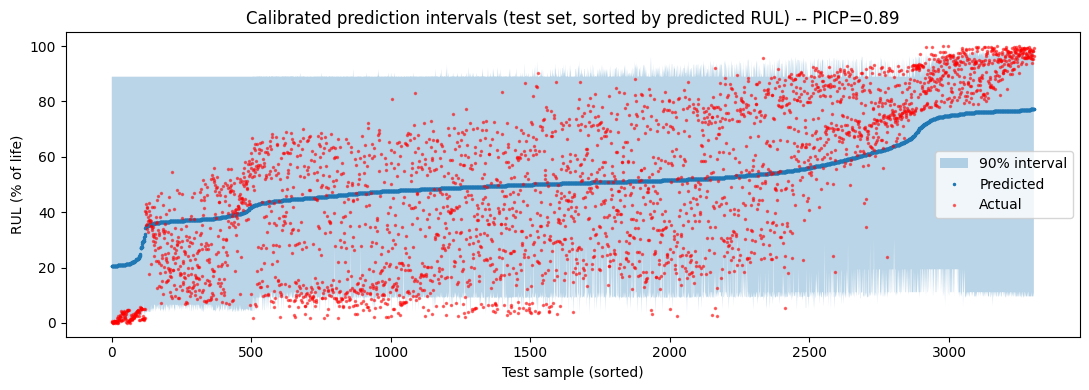

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
order = np.argsort(test_point)
ax.fill_between(range(len(test_point)), test_lo[order], test_hi[order], alpha=0.3, label="90% interval")
ax.plot(range(len(test_point)), test_point[order], '.', markersize=3, label="Predicted")
ax.plot(range(len(test_point)), y_test.values[order], 'r.', markersize=3, alpha=0.5, label="Actual")
ax.set_title(f"Calibrated prediction intervals (test set, sorted by predicted RUL) -- PICP={PICP:.2f}")
ax.set_xlabel("Test sample (sorted)")
ax.set_ylabel("RUL (% of life)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "prediction_intervals_plot.png"), dpi=130)
plt.show()


In [14]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
global_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)

print("Top 10 features by global SHAP importance:")
print(global_importance.head(10))


Top 10 features by global SHAP importance:
horiz_band_energy_2        5.338261
horiz_band_energy_5        2.569033
horiz_std                  2.216218
horiz_shape_factor         1.865223
horiz_variance             1.668256
horiz_peak                 1.077551
horiz_spectral_std_freq    0.917724
vert_band_energy_1         0.778221
horiz_kurtosis             0.609701
vert_kurtosis              0.476012
dtype: float64


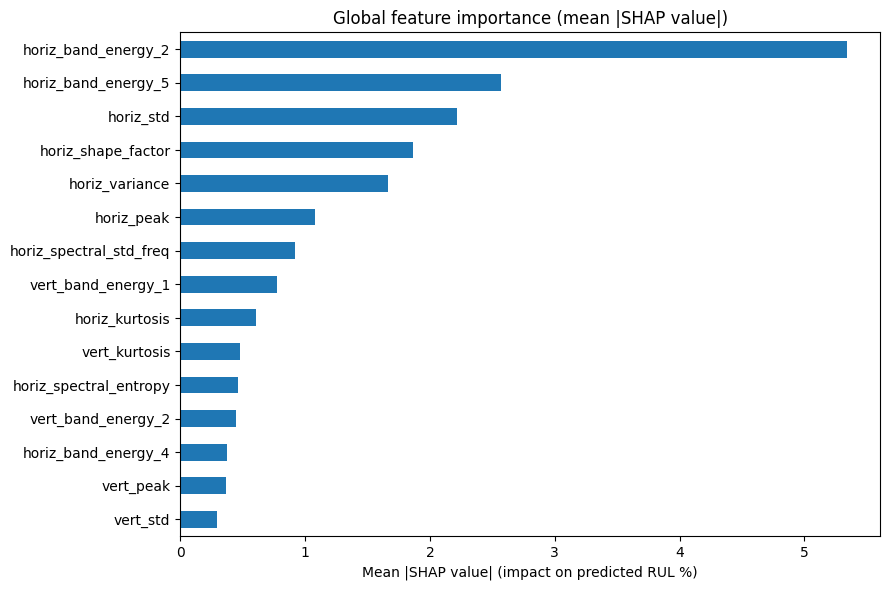

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
global_importance.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Global feature importance (mean |SHAP value|)")
ax.set_xlabel("Mean |SHAP value| (impact on predicted RUL %)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_global_importance.png"), dpi=130)
plt.show()


In [16]:
# Save full local SHAP values (one row per test sample, one column per feature) + top-driver summary
shap_values_df = pd.DataFrame(shap_values, columns=[f"shap_{c}" for c in feature_cols])
shap_values_df.insert(0, "bearing", test_df["bearing"].values)
shap_values_df.insert(1, "snapshot_idx", test_df["snapshot_idx"].values)

# Per-sample top-3 driving features (largest |SHAP| for that specific prediction), not just the
# single top driver -- an engineer benefits from seeing the top few contributing factors, not one.
N_TOP_DRIVERS = 3
abs_shap = np.abs(shap_values)
top_idx = np.argsort(-abs_shap, axis=1)[:, :N_TOP_DRIVERS]

for rank in range(N_TOP_DRIVERS):
    feat_names = [feature_cols[top_idx[row, rank]] for row in range(len(top_idx))]
    feat_vals = [shap_values[row, top_idx[row, rank]] for row in range(len(top_idx))]
    shap_values_df[f"top_driver_{rank+1}_feature"] = feat_names
    shap_values_df[f"top_driver_{rank+1}_shap_value"] = feat_vals

# Human-readable explanation string, e.g. "horiz_wavelet_detail_2_energy_ratio (+4.2), horiz_peak (-1.8), ..."
def _format_explanation(row):
    parts = []
    for rank in range(1, N_TOP_DRIVERS + 1):
        feat = row[f"top_driver_{rank}_feature"]
        val = row[f"top_driver_{rank}_shap_value"]
        parts.append(f"{feat} ({val:+.2f})")
    return "; ".join(parts)

shap_values_df["explanation"] = shap_values_df.apply(_format_explanation, axis=1)

# Keep the single top driver columns too, for backward compatibility with anything already using them
shap_values_df["top_driver_feature"] = shap_values_df["top_driver_1_feature"]
shap_values_df["top_driver_shap_value"] = shap_values_df["top_driver_1_shap_value"]

shap_path = os.path.join(OUTPUT_DIR, "shap_values.csv")
shap_values_df.to_csv(shap_path, index=False)
print(f"Saved -> {shap_path}  {shap_values_df.shape}")
shap_values_df[["bearing", "snapshot_idx", "explanation"]].head(10)


Saved -> /content/drive/MyDrive/FEMTO-ST/chapter6_outputs/shap_values.csv  (3305, 41)


,bearing,snapshot_idx,explanation
0,Bearing1_2,1,horiz_band_energy_2 (+11.62); horiz_spectral_s...
1,Bearing1_2,2,horiz_band_energy_2 (+11.17); horiz_spectral_s...
2,Bearing1_2,3,horiz_band_energy_2 (+10.93); horiz_spectral_s...
3,Bearing1_2,4,horiz_band_energy_2 (+10.89); horiz_spectral_s...
4,Bearing1_2,5,horiz_band_energy_2 (+10.84); horiz_spectral_s...
5,Bearing1_2,6,horiz_band_energy_2 (+10.71); horiz_spectral_s...
6,Bearing1_2,7,horiz_band_energy_2 (+10.77); horiz_spectral_s...
7,Bearing1_2,8,horiz_band_energy_2 (+11.17); horiz_spectral_s...
8,Bearing1_2,9,horiz_band_energy_2 (+10.58); horiz_spectral_s...
9,Bearing1_2,10,horiz_band_energy_2 (+9.94); horiz_spectral_st...


In [17]:
LOW_RUL_THRESHOLD = 20
HIGH_RUL_THRESHOLD = 40
width_median = np.median(test_width)


def confidence_aware_action_legacy(rul_pct, interval_width):
    """Original Chapter 6 policy (point-RUL-only branching) -- kept for comparison, no longer
    the framework's primary recommendation."""
    if rul_pct < LOW_RUL_THRESHOLD:
        return "Replace immediately" if interval_width < width_median else "Inspect before replacement"
    elif rul_pct < HIGH_RUL_THRESHOLD:
        return "Schedule maintenance"
    else:
        return "Continue monitoring"


def risk_aware_action(point_rul, lower_bound):
    """Revised policy: gates on the CQR lower bound (plausible downside), not just the point
    estimate -- fixes the hidden-risk failure mode found in Chapter 7, Experiment 7."""
    if lower_bound < LOW_RUL_THRESHOLD:
        return "Replace immediately" if point_rul < LOW_RUL_THRESHOLD else "Inspect before replacement"
    elif point_rul < HIGH_RUL_THRESHOLD:
        return "Schedule maintenance"
    else:
        return "Continue monitoring"


legacy_actions = [confidence_aware_action_legacy(r, w) for r, w in zip(test_point, test_width)]
new_actions = [risk_aware_action(r, l) for r, l in zip(test_point, test_lo)]

maintenance_recommendations = prediction_with_intervals.copy()
maintenance_recommendations["top_driver_1_feature"] = shap_values_df["top_driver_1_feature"].values
maintenance_recommendations["top_driver_1_shap_value"] = shap_values_df["top_driver_1_shap_value"].values
maintenance_recommendations["top_driver_2_feature"] = shap_values_df["top_driver_2_feature"].values
maintenance_recommendations["top_driver_2_shap_value"] = shap_values_df["top_driver_2_shap_value"].values
maintenance_recommendations["top_driver_3_feature"] = shap_values_df["top_driver_3_feature"].values
maintenance_recommendations["top_driver_3_shap_value"] = shap_values_df["top_driver_3_shap_value"].values
maintenance_recommendations["explanation"] = shap_values_df["explanation"].values
maintenance_recommendations["confidence_aware_action_legacy"] = legacy_actions
maintenance_recommendations["risk_aware_action"] = new_actions
maintenance_recommendations["recommended_action"] = new_actions  # risk-aware is now the primary policy

rec_path = os.path.join(OUTPUT_DIR, "maintenance_recommendations.csv")
maintenance_recommendations.to_csv(rec_path, index=False)
print(f"Saved -> {rec_path}  {maintenance_recommendations.shape}")
print("\nRevised (risk-aware) action distribution:")
print(maintenance_recommendations["recommended_action"].value_counts())
print("\nLegacy (confidence-aware) action distribution, for comparison:")
print(maintenance_recommendations["confidence_aware_action_legacy"].value_counts())

n_missed_legacy = ((maintenance_recommendations["actual_RUL_pct"] < 20) &
                    (maintenance_recommendations["confidence_aware_action_legacy"] == "Continue monitoring")).sum()
n_missed_new = ((maintenance_recommendations["actual_RUL_pct"] < 20) &
                (maintenance_recommendations["recommended_action"] == "Continue monitoring")).sum()
print(f"\nCritical cases (true RUL<20%) assigned 'Continue monitoring': "
      f"legacy={n_missed_legacy}, revised={n_missed_new}")
maintenance_recommendations[["bearing", "snapshot_idx", "predicted_RUL_pct", "lower_bound_pct",
                              "confidence_aware_action_legacy", "risk_aware_action"]].head(10)


Saved -> /content/drive/MyDrive/FEMTO-ST/chapter6_outputs/maintenance_recommendations.csv  (3305, 20)

Revised (risk-aware) action distribution:
recommended_action
Inspect before replacement    3236
Continue monitoring             69
Name: count, dtype: int64

Legacy (confidence-aware) action distribution, for comparison:
confidence_aware_action_legacy
Continue monitoring     2827
Schedule maintenance     478
Name: count, dtype: int64

Critical cases (true RUL<20%) assigned 'Continue monitoring': legacy=438, revised=1


,bearing,snapshot_idx,predicted_RUL_pct,lower_bound_pct,confidence_aware_action_legacy,risk_aware_action
0,Bearing1_2,1,74.791506,9.406838,Continue monitoring,Inspect before replacement
1,Bearing1_2,2,76.643122,9.412666,Continue monitoring,Inspect before replacement
2,Bearing1_2,3,76.182195,9.419085,Continue monitoring,Inspect before replacement
3,Bearing1_2,4,76.500638,9.090974,Continue monitoring,Inspect before replacement
4,Bearing1_2,5,76.806064,9.090974,Continue monitoring,Inspect before replacement
5,Bearing1_2,6,76.746582,9.090974,Continue monitoring,Inspect before replacement
6,Bearing1_2,7,76.343681,9.090974,Continue monitoring,Inspect before replacement
7,Bearing1_2,8,75.908194,9.680334,Continue monitoring,Inspect before replacement
8,Bearing1_2,9,75.676696,9.452078,Continue monitoring,Inspect before replacement
9,Bearing1_2,10,75.756740,9.680334,Continue monitoring,Inspect before replacement


In [18]:
framework_results = maintenance_recommendations.copy()
framework_results["covered_by_interval"] = covered

framework_path = os.path.join(OUTPUT_DIR, "framework_results.csv")
framework_results.to_csv(framework_path, index=False)
print(f"Saved -> {framework_path}  {framework_results.shape}")
framework_results.head(10)


Saved -> /content/drive/MyDrive/FEMTO-ST/chapter6_outputs/framework_results.csv  (3305, 21)


,bearing,condition,snapshot_idx,RUL_snapshots,actual_RUL_pct,predicted_RUL_pct,lower_bound_pct,upper_bound_pct,interval_width_pct,confidence,top_driver_1_feature,top_driver_1_shap_value,top_driver_2_feature,top_driver_2_shap_value,top_driver_3_feature,top_driver_3_shap_value,explanation,confidence_aware_action_legacy,risk_aware_action,recommended_action,covered_by_interval
0,Bearing1_2,Condition 1,1,870,99.885189,74.791506,9.406838,98.099268,88.692430,Low,horiz_band_energy_2,11.620359,horiz_spectral_std_freq,3.465984,horiz_band_energy_5,2.669453,horiz_band_energy_2 (+11.62); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
1,Bearing1_2,Condition 1,2,869,99.770379,76.643122,9.412666,98.099268,88.686602,Low,horiz_band_energy_2,11.169385,horiz_spectral_std_freq,3.127466,horiz_band_energy_5,2.791079,horiz_band_energy_2 (+11.17); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
2,Bearing1_2,Condition 1,3,868,99.655568,76.182195,9.419085,97.994776,88.575691,Low,horiz_band_energy_2,10.927242,horiz_spectral_std_freq,3.213352,horiz_band_energy_5,2.625155,horiz_band_energy_2 (+10.93); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
3,Bearing1_2,Condition 1,4,867,99.540758,76.500638,9.090974,97.994776,88.903802,Low,horiz_band_energy_2,10.888813,horiz_spectral_std_freq,3.071069,horiz_band_energy_5,2.630212,horiz_band_energy_2 (+10.89); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
4,Bearing1_2,Condition 1,5,866,99.425947,76.806064,9.090974,98.015398,88.924425,Low,horiz_band_energy_2,10.842992,horiz_spectral_std_freq,3.054890,horiz_band_energy_5,2.571843,horiz_band_energy_2 (+10.84); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
5,Bearing1_2,Condition 1,6,865,99.311137,76.746582,9.090974,98.084551,88.993577,Low,horiz_band_energy_2,10.708411,horiz_spectral_std_freq,2.989051,horiz_band_energy_5,2.584727,horiz_band_energy_2 (+10.71); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
6,Bearing1_2,Condition 1,7,864,99.196326,76.343681,9.090974,98.012224,88.921251,Low,horiz_band_energy_2,10.766952,horiz_spectral_std_freq,3.022647,horiz_band_energy_5,2.568333,horiz_band_energy_2 (+10.77); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
7,Bearing1_2,Condition 1,8,863,99.081515,75.908194,9.680334,97.917818,88.237484,Low,horiz_band_energy_2,11.173061,horiz_spectral_std_freq,3.240687,horiz_band_energy_5,2.419582,horiz_band_energy_2 (+11.17); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
8,Bearing1_2,Condition 1,9,862,98.966705,75.676696,9.452078,97.050814,87.598736,Low,horiz_band_energy_2,10.579028,horiz_spectral_std_freq,2.686729,horiz_band_energy_5,2.435195,horiz_band_energy_2 (+10.58); horiz_spectral_s...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
9,Bearing1_2,Condition 1,10,861,98.851894,75.756740,9.680334,97.159571,87.479237,Low,horiz_band_energy_2,9.939312,horiz_spectral_std_freq,2.646269,horiz_band_energy_5,2.152571,horiz_band_energy_2 (+9.94); horiz_spectral_st...,Continue monitoring,Inspect before replacement,Inspect before replacement,False
